<a href="https://colab.research.google.com/github/nirmalprabhakarc/Machine-Learning-Alogarithms/blob/main/GH1052212_Bike_Sharing_Demand_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GH1052212: CHIRUKURI NIRMAL PRABHAKAR

# Bike-Sharing Demand Prediction Using Machine Learning

## 1.Project Overview

This project uses a machine learning model that is end-to-end supervised to predict bikes-sharing. This is posed as a regression problem, in which the number of rented bikes count is forecasted by the temporal, environmental and operational variables. The project includes data exploration, data quality analysis, feature engineering, preprocessing, model comparison, hyperparameter optimisation, final evaluation and business interpretation.

## 2. Problem Definition

The bike-sharing operators need to be able to plan their operations and predict the demand of a rental so that they can in turn have operational resources planned based on the projected usage. Decisions related to bike availability, staffing, maintenance, and operational plans over the short-term can be supported with accurate demand prediction.
The machine learning problem is stated as a supervised regression since the target variable, count, is a numeric value of the overall number of bike rentals. The model takes into account data in advance or even during a rental term, such as weather, calendar and time features, and predicts demand (Bobbo et al., 2026).
Casual and registered are not included in the analysis as predictors since these variables directly affect the overall number. They would introduce leakage to the target, and would not give a realistic prediction scenario.
The main aim is therefore to create an efficient scikit-learn pipeline, compare its results with alternative preprocessing and regression models, tune some important hyperparameters, and assess the resulting model using an unseen hold-out data.


In [ ]:
# ============================================================
# M505 BIKE-SHARING DEMAND PREDICTION
# Library imports and project configuration
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")
print("Random state:", RANDOM_STATE)

Libraries imported successfully.
Random state: 42


## 3. Data Collection

The labelled development dataset is the supplied train.csv file since it has the number of target variables. The test.csv used will involve data on the predictors, but it will not have count, making it unable to be read to obtain the metrics of supervised evaluation (Chen and Shan, 2026).
To perform the evaluation, an in-house training/test split is therefore created on the labelled training data. It is optional and the external test file provided is saved to give a demonstration of prediction when the final model is developed.
Dataset source: [https://www.kaggle.com/datasets/m0hand/bike-sharing-demand-prediction]
The data set has time-based, calendar and weather data along with the number of rentals. The variables are good enough to be utilised in exploratory analysis, feature engineering, model comparison and regression evaluation.


In [ ]:
# ============================================================
# Load datasets
# ============================================================

TRAIN_FILE = "train.csv"
TEST_FILE = "test.csv"

df = pd.read_csv(TRAIN_FILE)
external_test = pd.read_csv(TEST_FILE)

print("Training dataset shape:", df.shape)
print("External test dataset shape:", external_test.shape)

Training dataset shape: (10886, 12)
External test dataset shape: (6493, 9)


In [ ]:
# First five observations
display(df.head())

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.840,14.395,81,0.000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.020,13.635,80,0.000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.020,13.635,80,0.000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.840,14.395,75,0.000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.840,14.395,75,0.000,0,1,1


In [ ]:
# First five observations
display(df.head())

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.840,14.395,81,0.000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.020,13.635,80,0.000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.020,13.635,80,0.000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.840,14.395,75,0.000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.840,14.395,75,0.000,0,1,1


In [ ]:
# Last five observations
display(df.tail())

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
10881,2012-12-19 19:00:00,4,0,1,1,15.580,19.695,50,26.003,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.760,17.425,57,15.001,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.940,15.910,61,15.001,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.940,17.425,61,6.003,12,117,129
10885,2012-12-19 23:00:00,4,0,1,1,13.120,16.665,66,8.998,4,84,88


In [ ]:
# Dataset dimensions
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of observations: 10886
Number of variables: 12


### 4. Initial Dataset Observation

The training data has 10,886 observations and 12 variables. The variables consist of a date field, calendar features, weather measures and rental features. The response variable is count.
The dataset also has casual and registered. These variables are not taken as predictors since the value of these variables is added to the total number of rentals. They are hence eliminated prior to model development so as to avoid information leakage.


In [ ]:
# ============================================================
# Dataset structure
# ============================================================

print("Dataset information:\n")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

Dataset information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB

Column names:
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']


In [ ]:
# ============================================================
# Dataset structure
# ============================================================

print("Dataset information:\n")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

Dataset information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB

Column names:
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']


## 5. Exploratory Data Analysis

Exploratory analysis is used to identify the data structure, data quality and statistics of the data before modelling. It examines missing values, observation repeats, descriptive statistics, targeted distribution and correlation of demand and the variables selected to explain demand (Chen, Thakuriah and Ampountolas, 2021).
Significance of such checks is that the preprocessing and model selection should be performed using the observed characteristics of data and not assumptions.


In [ ]:
# ============================================================
# Missing-value analysis
# ============================================================

missing_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

display(missing_summary)

,Feature,Missing_Count,Missing_Percentage
datetime,datetime,0,0.000
season,season,0,0.000
holiday,holiday,0,0.000
workingday,workingday,0,0.000
weather,weather,0,0.000
temp,temp,0,0.000
atemp,atemp,0,0.000
humidity,humidity,0,0.000
windspeed,windspeed,0,0.000
casual,casual,0,0.000


### 6.Data Quality Interpretation

The missing and duplicates checks determine that it is important to clean up the data explicitly prior to modelling. In case of missing values, the pipeline will deal with them with scikit-learn imputers. In case no missing values are detected, the imputation steps can be used as a component of a powerful reusable pipeline (Corrias, Gjoreski and Langheinrich, 2023).
Duplicated records are analysed prior to modelling since multiple observations may impact on descriptive statistics and training of models.


In [ ]:
# ============================================================
# Descriptive statistics
# ============================================================

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
datetime,10886,10886,2012-12-19 23:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,"10,886.000",NaN,NaN,NaN,2.507,1.116,1.000,2.000,3.000,4.000,4.000
holiday,"10,886.000",NaN,NaN,NaN,0.029,0.167,0.000,0.000,0.000,0.000,1.000
workingday,"10,886.000",NaN,NaN,NaN,0.681,0.466,0.000,0.000,1.000,1.000,1.000
weather,"10,886.000",NaN,NaN,NaN,1.418,0.634,1.000,1.000,1.000,2.000,4.000
temp,"10,886.000",NaN,NaN,NaN,20.231,7.792,0.820,13.940,20.500,26.240,41.000
atemp,"10,886.000",NaN,NaN,NaN,23.655,8.475,0.760,16.665,24.240,31.060,45.455
humidity,"10,886.000",NaN,NaN,NaN,61.886,19.245,0.000,47.000,62.000,77.000,100.000
windspeed,"10,886.000",NaN,NaN,NaN,12.799,8.165,0.000,7.002,12.998,16.998,56.997
casual,"10,886.000",NaN,NaN,NaN,36.022,49.960,0.000,4.000,17.000,49.000,367.000


In [ ]:
# ============================================================
# Target variable summary
# ============================================================

target_summary = pd.Series({
    "Mean": df["count"].mean(),
    "Median": df["count"].median(),
    "Minimum": df["count"].min(),
    "Maximum": df["count"].max(),
    "Standard Deviation": df["count"].std()
})

display(target_summary.to_frame("Value"))

,Value
Mean,191.574
Median,145.000
Minimum,1.000
Maximum,977.000
Standard Deviation,181.144


### 7. Target Variable
The count of bikes is the target variable, which is the demand of the number of bikes that were rented. Its descriptive statistics give details on the central tendency and dispersion of demand (Del-Coco et al., 2025). The visualisation of distribution comes next since regression performance is sensitive to highly dispersed or extreme target values.

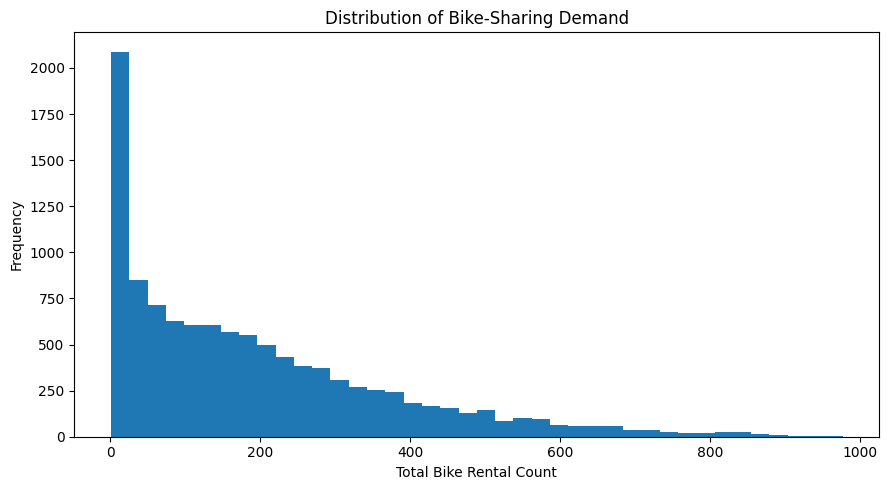

In [ ]:
# ============================================================
# Target distribution
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    df["count"],
    bins=40
)

plt.xlabel("Total Bike Rental Count")
plt.ylabel("Frequency")
plt.title("Distribution of Bike-Sharing Demand")

plt.tight_layout()
plt.show()

The target distribution needs to be interpreted applying to the spread and concentration. Long tails or extreme observations should be identified as they can add disproportionately to prediction error. Extreme observations are not necessarily eliminated as they can represent those real high-demand periods.

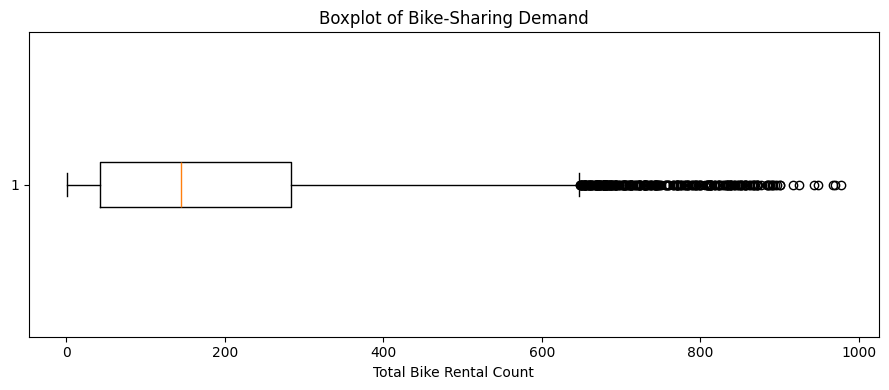

In [ ]:
# ============================================================
# Target boxplot
# ============================================================

plt.figure(figsize=(9, 4))

plt.boxplot(
    df["count"],
    vert=False
)

plt.xlabel("Total Bike Rental Count")
plt.title("Boxplot of Bike-Sharing Demand")

plt.tight_layout()
plt.show()

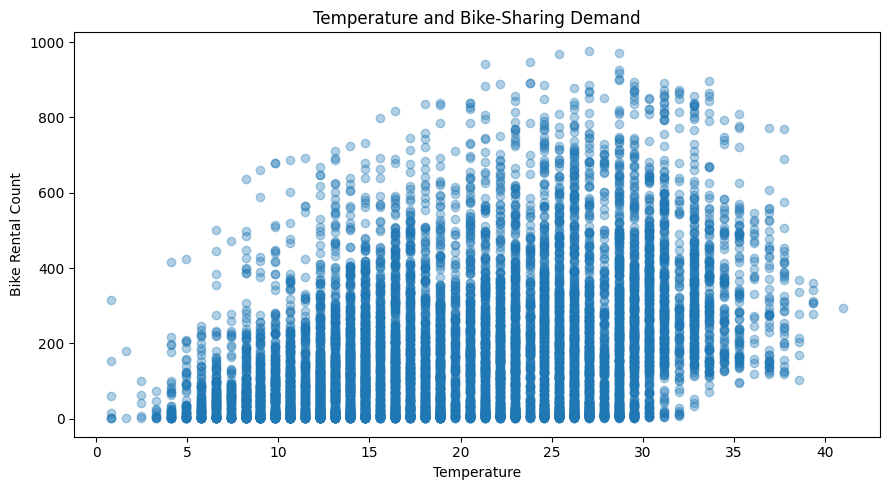

In [ ]:
# ============================================================
# Feature visualisation 1
# Temperature versus demand
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    df["temp"],
    df["count"],
    alpha=0.35
)

plt.xlabel("Temperature")
plt.ylabel("Bike Rental Count")
plt.title("Temperature and Bike-Sharing Demand")

plt.tight_layout()
plt.show()

### 8. Temperature and Demand

The temperature plot will be used to investigate the question of the systematic change in demand at different temperatures (Islam and Dhanekula, 2024). The trend identified should be described in terms of the plotted data without making any claims of causality. The perceived correlation can be the reason to use temperature as a predictor and to admit that there are other factors that might influence demand.

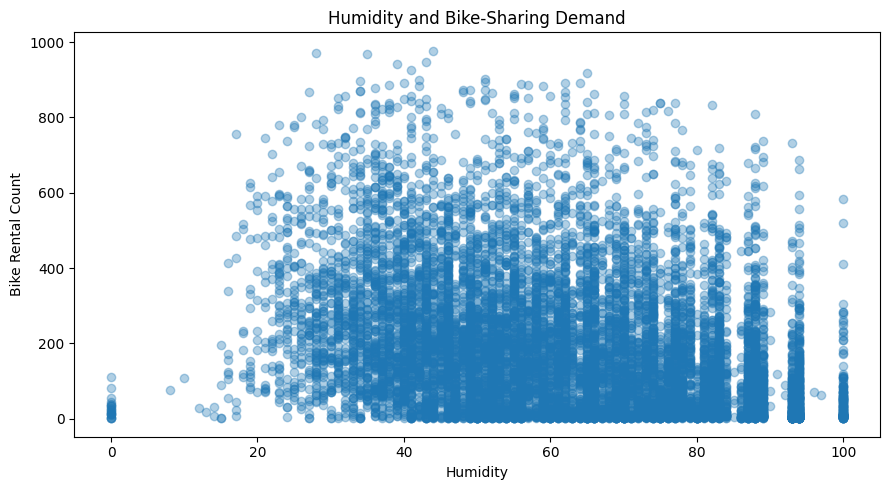

In [ ]:
# ============================================================
# Feature visualisation 2
# Humidity versus demand
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    df["humidity"],
    df["count"],
    alpha=0.35
)

plt.xlabel("Humidity")
plt.ylabel("Bike Rental Count")
plt.title("Humidity and Bike-Sharing Demand")

plt.tight_layout()
plt.show()

### 9. Humidity and Demand

The humidity plot provides the second view of the correlation between the environmental factors and demand. The interpretation of the predictive usefulness of humidity should take into consideration the distribution of observations and any apparent concentration or variation (Jin and Ma, 2026).

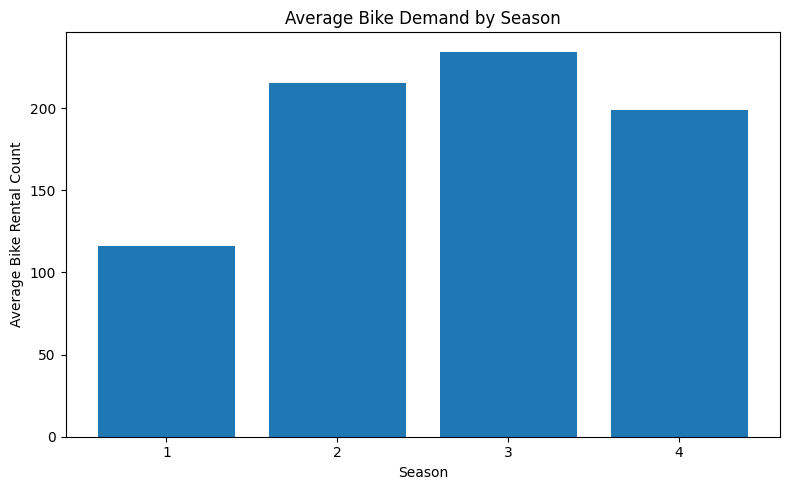

In [ ]:
# ============================================================
# Additional feature visualisation
# ============================================================

season_mean = (
    df.groupby("season")["count"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    season_mean.index.astype(str),
    season_mean.values
)

plt.xlabel("Season")
plt.ylabel("Average Bike Rental Count")
plt.title("Average Bike Demand by Season")

plt.tight_layout()
plt.show()

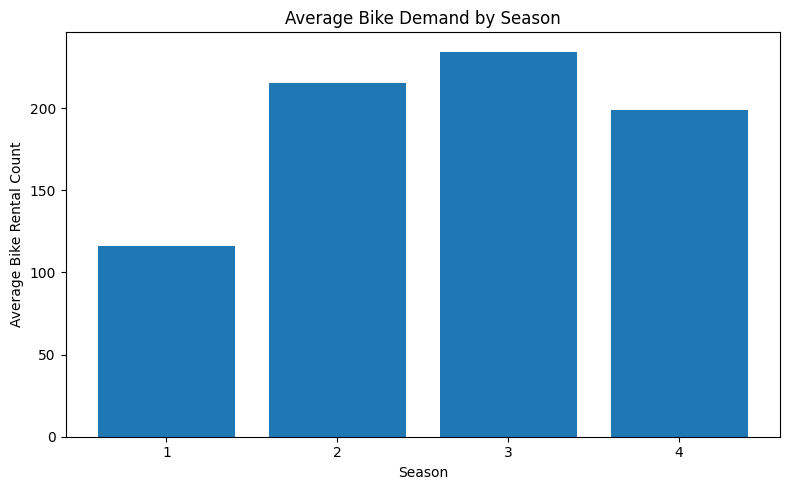

In [ ]:
# ============================================================
# Additional feature visualisation
# ============================================================

season_mean = (
    df.groupby("season")["count"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    season_mean.index.astype(str),
    season_mean.values
)

plt.xlabel("Season")
plt.ylabel("Average Bike Rental Count")
plt.title("Average Bike Demand by Season")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Correlation analysis for numerical variables
# ============================================================

numeric_eda = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_eda.corr()

display(correlation_matrix.round(2))

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.000,0.030,-0.010,0.010,0.260,0.260,0.190,-0.150,0.100,0.160,0.160
holiday,0.030,1.000,-0.250,-0.010,0.000,-0.010,0.000,0.010,0.040,-0.020,-0.010
workingday,-0.010,-0.250,1.000,0.030,0.030,0.020,-0.010,0.010,-0.320,0.120,0.010
weather,0.010,-0.010,0.030,1.000,-0.060,-0.060,0.410,0.010,-0.140,-0.110,-0.130
temp,0.260,0.000,0.030,-0.060,1.000,0.980,-0.060,-0.020,0.470,0.320,0.390
atemp,0.260,-0.010,0.020,-0.060,0.980,1.000,-0.040,-0.060,0.460,0.310,0.390
humidity,0.190,0.000,-0.010,0.410,-0.060,-0.040,1.000,-0.320,-0.350,-0.270,-0.320
windspeed,-0.150,0.010,0.010,0.010,-0.020,-0.060,-0.320,1.000,0.090,0.090,0.100
casual,0.100,0.040,-0.320,-0.140,0.470,0.460,-0.350,0.090,1.000,0.500,0.690
registered,0.160,-0.020,0.120,-0.110,0.320,0.310,-0.270,0.090,0.500,1.000,0.970


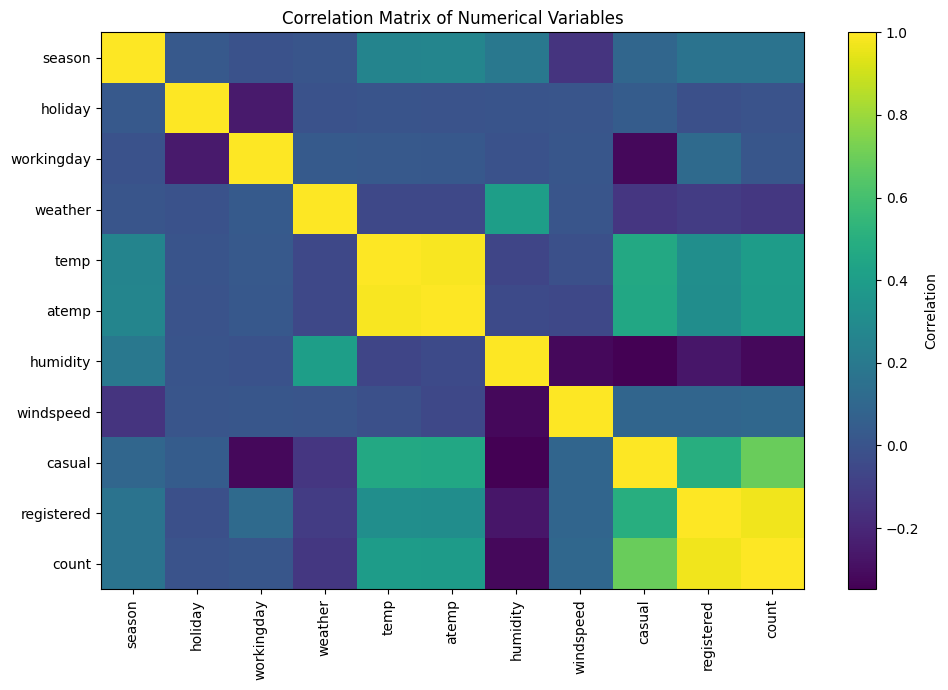

In [ ]:
# ============================================================
# Correlation heatmap using matplotlib
# ============================================================

plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

## 10. Data Cleaning and Feature Engineering

The modelling dataset is constructed based on the isolation of the target and the explanatory variables and the removal of the variables that would result in a leakage of the target (Khulbe, Belyi and Sobolevsky, 2025). The date time variable is transformed into meaningful time characteristics because the demand of rentals can vary regarding the number of hours, days, months and years.
One-hot encoding of categorical variables is employed and numerical variables are imputed where needed. One of the preprocessing strategies includes standardisation as an element to be able to compare its impact empirically.


In [ ]:
# ============================================================
# Convert datetime fields
# ============================================================

df["datetime"] = pd.to_datetime(
    df["datetime"]
)

external_test["datetime"] = pd.to_datetime(
    external_test["datetime"]
)

print("Datetime conversion completed.")
print("Training period:")
print(df["datetime"].min(), "to", df["datetime"].max())

Datetime conversion completed.
Training period:
2011-01-01 00:00:00 to 2012-12-19 23:00:00


In [ ]:
# ============================================================
# Reproducible datetime feature engineering
# ============================================================

def create_features(data):
    data = data.copy()

    data["year"] = data["datetime"].dt.year
    data["month"] = data["datetime"].dt.month
    data["day"] = data["datetime"].dt.day
    data["hour"] = data["datetime"].dt.hour
    data["day_of_week"] = data["datetime"].dt.dayofweek

    data = data.drop(
        columns=["datetime"]
    )

    return data

In [ ]:
# ============================================================
# Apply feature engineering
# ============================================================

df_model = create_features(df)
external_test_model = create_features(
    external_test
)

display(df_model.head())

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,day_of_week
0,1,0,0,1,9.840,14.395,81,0.000,3,13,16,2011,1,1,0,5
1,1,0,0,1,9.020,13.635,80,0.000,8,32,40,2011,1,1,1,5
2,1,0,0,1,9.020,13.635,80,0.000,5,27,32,2011,1,1,2,5
3,1,0,0,1,9.840,14.395,75,0.000,3,10,13,2011,1,1,3,5
4,1,0,0,1,9.840,14.395,75,0.000,0,1,1,2011,1,1,4,5


In [ ]:
# ============================================================
# Define target and remove leakage variables
# ============================================================

TARGET = "count"

LEAKAGE_COLUMNS = [
    "casual",
    "registered"
]

X = df_model.drop(
    columns=[TARGET] + LEAKAGE_COLUMNS
)

y = df_model[TARGET]

print("Target:", TARGET)

print("\nPredictor variables:")
for feature in X.columns:
    print("-", feature)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Target: count

Predictor variables:
- season
- holiday
- workingday
- weather
- temp
- atemp
- humidity
- windspeed
- year
- month
- day
- hour
- day_of_week

X shape: (10886, 13)
y shape: (10886,)


### 11. Target Leakage Control

The excluded variables are casual and registered since the total number is built by using these elements. Their use would enable the model to reach information that is directly correlated with the being predicted value. The removal of these factors results in a more appropriate prediction context with the help of calendar and environmental information (Kruschel et al., 2026).

In [ ]:
# ============================================================
# Hold-out test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training observations:", len(X_train))
print("Hold-out test observations:", len(X_test))

Training observations: 8708
Hold-out test observations: 2178


### 12. Train-Test Method

Twenty percent of the labelled observations are reserved as a final hold-out test set. Observations in the test are not utilised to fit preprocessing changes, choose hyperparameters or train the final model. A constant random state provides reproducibility (Mohamed, Mohamed and Maatouk, 2025). This division allows the performance end evaluation to be judged based on the observations that are not used in the development of the model.

In [ ]:
# ============================================================
# Define numerical and categorical variables
# ============================================================

categorical_features = [
    "season",
    "holiday",
    "workingday",
    "weather"
]

numerical_features = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['season', 'holiday', 'workingday', 'weather']

Numerical features:
['temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'day_of_week']


## 13. Preprocessing Strategy A

Strategy A employs median imputation of numerical variables, most-frequent imputation and then one-hot encoding of categorical variables. No scaling is applied to numerical variables (Mundada et al., 2026).
This is the approach that can be utilised to compare the effect of scaling.


In [ ]:
# ============================================================
# DEFINE FEATURE GROUPS
# ============================================================

# Categorical variables
categorical_features = [
    "season",
    "holiday",
    "workingday",
    "weather"
]

# Numerical variables
numerical_features = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['season', 'holiday', 'workingday', 'weather']

Numerical features:
['temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'day_of_week']


In [ ]:
# PREPROCESSING STRATEGY A
# Imputation + One-Hot Encoding
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
numeric_A = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

# Categorical preprocessing
categorical_A = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

# Combined preprocessing
preprocessor_A = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_A,
            numerical_features
        ),
        (
            "categorical",
            categorical_A,
            categorical_features
        )
    ]
)

print("Preprocessing Strategy A created successfully.")

Preprocessing Strategy A created successfully.


## 14. Preprocessing Strategy B

Strategy B adapts Strategy A in terms of handling missing values and using categorical encoding but introduces StandardScaler to numeric features. Scaling standardizes the numerical variables, and empirically examines whether or not the standardisation will affect the performance of the regression model (Peng et al., 2024).

In [ ]:
# ============================================================
# MASTER IMPORT CELL
# Run this once before the machine-learning sections
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42

print("All required libraries are ready.")

All required libraries are ready.


In [ ]:
# ============================================================
# PREPROCESSING STRATEGY B
# Imputation + Standard Scaling + One-Hot Encoding
# ============================================================

# Required imports
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# Numerical preprocessing
# Median imputation + StandardScaler
# ------------------------------------------------------------

numeric_B = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ------------------------------------------------------------
# Categorical preprocessing
# Most-frequent imputation + One-Hot Encoding
# ------------------------------------------------------------

categorical_B = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

# ------------------------------------------------------------
# Combine numerical and categorical preprocessing
# ------------------------------------------------------------

preprocessor_B = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_B,
            numerical_features
        ),
        (
            "categorical",
            categorical_B,
            categorical_features
        )
    ]
)

print("Preprocessing Strategy B created successfully.")
print("\nNumerical preprocessing:")
print("Median imputation → StandardScaler")

print("\nCategorical preprocessing:")
print("Most-frequent imputation → OneHotEncoder")

Preprocessing Strategy B created successfully.

Numerical preprocessing:
Median imputation → StandardScaler

Categorical preprocessing:
Most-frequent imputation → OneHotEncoder


In [ ]:
import os

print("Searching for train.csv and test.csv...")

for root, dirs, files in os.walk("/"):
    # Ignore system folders that can cause unnecessary searching
    dirs[:] = [
        d for d in dirs
        if d not in [
            "proc", "sys", "dev", "usr", "opt"
        ]
    ]

    for file in files:
        if file.lower() in ["train.csv", "test.csv"]:
            print(
                "FOUND:",
                os.path.join(root, file)
            )

Searching for train.csv and test.csv...
FOUND: /train.csv
FOUND: /test.csv


In [ ]:
import pandas as pd
import numpy as np
import os

TRAIN_FILE = "/train.csv"
TEST_FILE = "/test.csv"

# Check files
print("Train file exists:", os.path.exists(TRAIN_FILE))
print("Test file exists:", os.path.exists(TEST_FILE))

# Load
df = pd.read_csv(TRAIN_FILE)
external_test = pd.read_csv(TEST_FILE)

print("\n" + "=" * 60)
print("DATASETS LOADED SUCCESSFULLY")
print("=" * 60)

print("\nTraining dataset shape:")
print(df.shape)

print("\nTest dataset shape:")
print(external_test.shape)

print("\nTraining columns:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

Train file exists: True
Test file exists: True

DATASETS LOADED SUCCESSFULLY

Training dataset shape:
(10886, 12)

Test dataset shape:
(6493, 9)

Training columns:
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

First five rows:


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
# Create a copy of the training dataset
df_model = df.copy()

# Convert datetime column to pandas datetime
df_model["datetime"] = pd.to_datetime(
    df_model["datetime"]
)

# Extract useful time-based features
df_model["year"] = df_model["datetime"].dt.year
df_model["month"] = df_model["datetime"].dt.month
df_model["day"] = df_model["datetime"].dt.day
df_model["hour"] = df_model["datetime"].dt.hour
df_model["day_of_week"] = df_model["datetime"].dt.dayofweek

# Remove original datetime column
df_model = df_model.drop(
    columns=["datetime"]
)

print("=" * 60)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 60)

print("\nNew dataset shape:")
print(df_model.shape)

print("\nColumns after feature engineering:")
print(df_model.columns.tolist())

print("\nFirst five rows:")
display(df_model.head())

FEATURE ENGINEERING COMPLETED

New dataset shape:
(10886, 16)

Columns after feature engineering:
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'year', 'month', 'day', 'hour', 'day_of_week']

First five rows:


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,day_of_week
0,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5
1,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5
2,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5
3,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5
4,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5


In [ ]:
TARGET = "count"

# Variables that would cause target leakage
LEAKAGE_COLUMNS = [
    "casual",
    "registered"
]

# Target variable
y = df_model[TARGET].copy()

# Predictor variables
X = df_model.drop(
    columns=[
        TARGET,
        "casual",
        "registered"
    ]
).copy()

print("=" * 60)
print("PREDICTORS AND TARGET CREATED")
print("=" * 60)

print("\nTarget variable:")
print(TARGET)

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

# Leakage verification
print("\nLeakage check:")
print("casual in X:", "casual" in X.columns)
print("registered in X:", "registered" in X.columns)
print("count in X:", "count" in X.columns)

PREDICTORS AND TARGET CREATED

Target variable:
count

Predictor columns:
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'day_of_week']

X shape: (10886, 13)
y shape: (10886,)

Leakage check:
casual in X: False
registered in X: False
count in X: False


In [ ]:
categorical_features = [
    "season",
    "holiday",
    "workingday",
    "weather"
]

numerical_features = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week"
]

print("=" * 60)
print("FEATURE GROUPS DEFINED")
print("=" * 60)

print("\nCategorical features:")
for feature in categorical_features:
    print("-", feature)

print("\nNumerical features:")
for feature in numerical_features:
    print("-", feature)

# Verify that every specified feature exists
missing_features = [
    feature
    for feature in categorical_features + numerical_features
    if feature not in X.columns
]

print("\nMissing features:", missing_features)

if len(missing_features) == 0:
    print("PASS - All modelling features are available.")
else:
    print("WARNING - Some features are missing.")

FEATURE GROUPS DEFINED

Categorical features:
- season
- holiday
- workingday
- weather

Numerical features:
- temp
- atemp
- humidity
- windspeed
- year
- month
- day
- hour
- day_of_week

Missing features: []
PASS - All modelling features are available.


In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("=" * 60)
print("TRAIN / TEST SPLIT COMPLETED")
print("=" * 60)

print("\nComplete dataset:")
print("X:", X.shape)
print("y:", y.shape)

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nHold-out test set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining percentage:")
print(round(len(X_train) / len(X) * 100, 2), "%")

print("\nTest percentage:")
print(round(len(X_test) / len(X) * 100, 2), "%")

TRAIN / TEST SPLIT COMPLETED

Complete dataset:
X: (10886, 13)
y: (10886,)

Training set:
X_train: (8708, 13)
y_train: (8708,)

Hold-out test set:
X_test: (2178, 13)
y_test: (2178,)

Training percentage:
79.99 %

Test percentage:
20.01 %


In [ ]:
print("=" * 60)
print("PRE-MODELLING VALIDATION")
print("=" * 60)

checks = {
    "df_model exists": "df_model" in globals(),
    "X exists": "X" in globals(),
    "y exists": "y" in globals(),
    "X_train exists": "X_train" in globals(),
    "X_test exists": "X_test" in globals(),
    "y_train exists": "y_train" in globals(),
    "y_test exists": "y_test" in globals(),
    "numerical_features exists": "numerical_features" in globals(),
    "categorical_features exists": "categorical_features" in globals()
}

for check, result in checks.items():
    print(
        f"{check}:",
        "PASS" if result else "FAIL"
    )

print("\nLeakage check:")

assert "casual" not in X.columns
assert "registered" not in X.columns
assert "count" not in X.columns

print("PASS - No target leakage detected.")

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

print("PASS - Predictor and target lengths match.")

print("\n" + "=" * 60)
print("DATA IS READY FOR MACHINE LEARNING")
print("=" * 60)

PRE-MODELLING VALIDATION
df_model exists: PASS
X exists: PASS
y exists: PASS
X_train exists: PASS
X_test exists: PASS
y_train exists: PASS
y_test exists: PASS
numerical_features exists: PASS
categorical_features exists: PASS

Leakage check:
PASS - No target leakage detected.
PASS - Predictor and target lengths match.

DATA IS READY FOR MACHINE LEARNING


In [ ]:
# ============================================================
# CELL 42 - MODELLING SETUP
# ============================================================

# Import all required libraries again to avoid missing-import
# errors if cells have been executed out of order.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Reproducibility
RANDOM_STATE = 42

# ------------------------------------------------------------
# Define feature groups
# ------------------------------------------------------------

categorical_features = [
    "season",
    "holiday",
    "workingday",
    "weather"
]

numerical_features = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week"
]

# ------------------------------------------------------------
# Check that all required variables exist
# ------------------------------------------------------------

required_variables = [
    "X_train",
    "X_test",
    "y_train",
    "y_test"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "The following variables are missing: "
        + ", ".join(missing_variables)
        + ". Please run the earlier data preparation cells first."
    )

print("Modelling environment ready.")
print("\nTraining features:", X_train.shape)
print("Hold-out test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Hold-out target:", y_test.shape)

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Modelling environment ready.

Training features: (8708, 13)
Hold-out test features: (2178, 13)
Training target: (8708,)
Hold-out target: (2178,)

Categorical features:
['season', 'holiday', 'workingday', 'weather']

Numerical features:
['temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'day_of_week']


## 15. Preprocessing Strategy A: Imputation and Encoding

The first preprocessing strategy applies median imputation to numerical variables and most-frequent imputation followed by one-hot encoding to categorical variables. No standardisation is applied to the numerical variables.

This strategy establishes a baseline preprocessing configuration. Ridge Regression is used to compare this approach with a second strategy that adds feature scaling.

In [ ]:
# ============================================================
# CELL 44 - RIDGE REGRESSION WITH STRATEGY A
# ============================================================

# Numerical preprocessing
numeric_A = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

# Categorical preprocessing
categorical_A = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine both preprocessing pipelines
preprocessor_A = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_A,
            numerical_features
        ),
        (
            "categorical",
            categorical_A,
            categorical_features
        )
    ]
)

# Complete Ridge pipeline
ridge_A = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_A
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

# Train
ridge_A.fit(
    X_train,
    y_train
)

# Predict
ridge_A_pred = ridge_A.predict(
    X_test
)

# Calculate metrics
ridge_A_mae = mean_absolute_error(
    y_test,
    ridge_A_pred
)

ridge_A_mse = mean_squared_error(
    y_test,
    ridge_A_pred
)

ridge_A_rmse = np.sqrt(
    ridge_A_mse
)

ridge_A_r2 = r2_score(
    y_test,
    ridge_A_pred
)

print("Ridge Regression - Strategy A")
print("-" * 45)
print(f"MAE  : {ridge_A_mae:.3f}")
print(f"MSE  : {ridge_A_mse:.3f}")
print(f"RMSE : {ridge_A_rmse:.3f}")
print(f"R²   : {ridge_A_r2:.3f}")

Ridge Regression - Strategy A
---------------------------------------------
MAE  : 105.087
MSE  : 19777.009
RMSE : 140.631
R²   : 0.401


## 16. Preprocessing Strategy B: Imputation, Scaling and Encoding

Strategy B adapts Strategy A in terms of handling missing values and using categorical encoding but introduces StandardScaler to numeric features. Scaling standardizes the numerical variables, and empirically examines whether or not the standardisation will affect the performance of the regression model (Peng et al., 2024).
The second method involves the same imputation and categorical encoding steps and involves the use of StandardScaler to numerical variables.
Standardisation converts the numerical variables to a similar scale. Its effect is an empirical test of it rather than the assumption that scaling should inevitably result in an increase in predictive performance (Somanath et al., 2024).
The Ridge Regression algorithm and hold-out observations are performed similarly to the comparison being based on the difference in the preprocessing.


In [ ]:
# ============================================================
# CELL 46 - RIDGE REGRESSION WITH STRATEGY B
# ============================================================

# Numerical preprocessing:
# Median imputation + StandardScaler
numeric_B = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing:
# Most-frequent imputation + OneHotEncoder
categorical_B = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combined preprocessing
preprocessor_B = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_B,
            numerical_features
        ),
        (
            "categorical",
            categorical_B,
            categorical_features
        )
    ]
)

# Complete Ridge pipeline
ridge_B = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_B
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

# Train
ridge_B.fit(
    X_train,
    y_train
)

# Predict
ridge_B_pred = ridge_B.predict(
    X_test
)

# Metrics
ridge_B_mae = mean_absolute_error(
    y_test,
    ridge_B_pred
)

ridge_B_mse = mean_squared_error(
    y_test,
    ridge_B_pred
)

ridge_B_rmse = np.sqrt(
    ridge_B_mse
)

ridge_B_r2 = r2_score(
    y_test,
    ridge_B_pred
)

print("Ridge Regression - Strategy B")
print("-" * 45)
print(f"MAE  : {ridge_B_mae:.3f}")
print(f"MSE  : {ridge_B_mse:.3f}")
print(f"RMSE : {ridge_B_rmse:.3f}")
print(f"R²   : {ridge_B_r2:.3f}")

Ridge Regression - Strategy B
---------------------------------------------
MAE  : 105.087
MSE  : 19776.952
RMSE : 140.631
R²   : 0.401


## 17. Comparison of Preprocessing Strategies

The regression algorithm is the identical one to compare the two preprocessing strategies. Strategy A imputes and encodes and Strategy B also standardises numerical variables (Chen, Thakuriah and Ampountolas, 2021).
Compared are the MAE, MSE, RMSE and R². Smaller MAE, MSE and RMSE are evidence of smaller prediction errors and higher R2 is evidence of more variation being explained.
The empirical comparison is associated with the results obtained: the results of scaling determine whether it is empirically helpful to the existing data set and modelling approach.


In [ ]:
# ============================================================
# CELL 48 - PREPROCESSING COMPARISON
# ============================================================

preprocessing_results = pd.DataFrame({
    "Strategy": [
        "Strategy A: Imputation + Encoding",
        "Strategy B: Imputation + Scaling + Encoding"
    ],
    "MAE": [
        ridge_A_mae,
        ridge_B_mae
    ],
    "MSE": [
        ridge_A_mse,
        ridge_B_mse
    ],
    "RMSE": [
        ridge_A_rmse,
        ridge_B_rmse
    ],
    "R2": [
        ridge_A_r2,
        ridge_B_r2
    ]
})

display(
    preprocessing_results.round(3)
)

,Strategy,MAE,MSE,RMSE,R2
0,Strategy A: Imputation + Encoding,105.087,19777.009,140.631,0.401
1,Strategy B: Imputation + Scaling + Encoding,105.087,19776.952,140.631,0.401


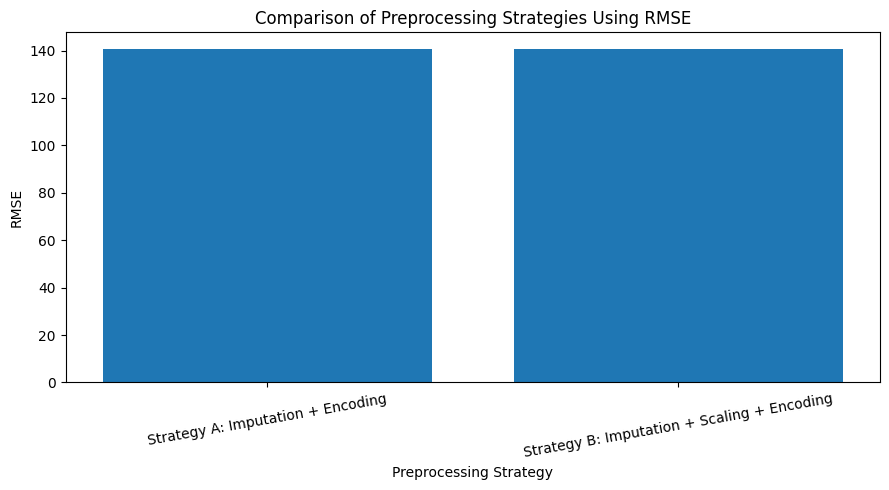

In [ ]:
# ============================================================
# CELL 49 - PREPROCESSING STRATEGY VISUALISATION
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    preprocessing_results["Strategy"],
    preprocessing_results["RMSE"]
)

plt.xlabel("Preprocessing Strategy")
plt.ylabel("RMSE")
plt.title(
    "Comparison of Preprocessing Strategies Using RMSE"
)

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

### 18. Preprocessing Comparison Interpretation

The observed values should be used to interpret the results above. When Strategy B results in smaller RMSE than Strategy A, the result is empirical evidence that the use of standardisation positively improved the Ridge model using this data. Scaling may be of slight use when this difference is small (Del-Coco et al., 2025). The comparison demonstrates the necessity to make preprocessing decisions based on experimental facts and not assumptions.

## 19. Regression Model Selection

Two regression techniques are taken into consideration. Ridge Regression gives a regularised linear model and the random forest regression is a nonlinear ensemble technique which is founded on numerous decision trees.
Ridge comes in handy since it is a relatively simple baseline, in the sense that it approximates additive relationships with preprocessing. Random Forest has the ability to imply nonlinear relationship and interaction without making the same linear assumptions.
Both of the models are used in scikit-learn pipelines in which preprocessing and model fitting are interrelated.


In [ ]:
# ============================================================
# CELL 52 - RIDGE BASELINE MODEL
# ============================================================

ridge_baseline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_B
        ),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

ridge_baseline.fit(
    X_train,
    y_train
)

ridge_baseline_pred = (
    ridge_baseline.predict(X_test)
)

ridge_baseline_mae = mean_absolute_error(
    y_test,
    ridge_baseline_pred
)

ridge_baseline_mse = mean_squared_error(
    y_test,
    ridge_baseline_pred
)

ridge_baseline_rmse = np.sqrt(
    ridge_baseline_mse
)

ridge_baseline_r2 = r2_score(
    y_test,
    ridge_baseline_pred
)

print("RIDGE REGRESSION BASELINE")
print("=" * 45)
print(f"MAE  : {ridge_baseline_mae:.3f}")
print(f"MSE  : {ridge_baseline_mse:.3f}")
print(f"RMSE : {ridge_baseline_rmse:.3f}")
print(f"R²   : {ridge_baseline_r2:.3f}")

RIDGE REGRESSION BASELINE
MAE  : 105.087
MSE  : 19776.952
RMSE : 140.631
R²   : 0.401


In [ ]:
# ============================================================
# CELL 53 - RANDOM FOREST BASELINE MODEL
# ============================================================

rf_baseline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_B
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

rf_baseline.fit(
    X_train,
    y_train
)

rf_baseline_pred = (
    rf_baseline.predict(X_test)
)

rf_baseline_mae = mean_absolute_error(
    y_test,
    rf_baseline_pred
)

rf_baseline_mse = mean_squared_error(
    y_test,
    rf_baseline_pred
)

rf_baseline_rmse = np.sqrt(
    rf_baseline_mse
)

rf_baseline_r2 = r2_score(
    y_test,
    rf_baseline_pred
)

print("RANDOM FOREST BASELINE")
print("=" * 45)
print(f"MAE  : {rf_baseline_mae:.3f}")
print(f"MSE  : {rf_baseline_mse:.3f}")
print(f"RMSE : {rf_baseline_rmse:.3f}")
print(f"R²   : {rf_baseline_r2:.3f}")

RANDOM FOREST BASELINE
MAE  : 24.331
MSE  : 1514.647
RMSE : 38.918
R²   : 0.954


In [ ]:
# ============================================================
# CELL 53 - RANDOM FOREST BASELINE MODEL
# ============================================================

rf_baseline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_B
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

rf_baseline.fit(
    X_train,
    y_train
)

rf_baseline_pred = (
    rf_baseline.predict(X_test)
)

rf_baseline_mae = mean_absolute_error(
    y_test,
    rf_baseline_pred
)

rf_baseline_mse = mean_squared_error(
    y_test,
    rf_baseline_pred
)

rf_baseline_rmse = np.sqrt(
    rf_baseline_mse
)

rf_baseline_r2 = r2_score(
    y_test,
    rf_baseline_pred
)

print("RANDOM FOREST BASELINE")
print("=" * 45)
print(f"MAE  : {rf_baseline_mae:.3f}")
print(f"MSE  : {rf_baseline_mse:.3f}")
print(f"RMSE : {rf_baseline_rmse:.3f}")
print(f"R²   : {rf_baseline_r2:.3f}")

RANDOM FOREST BASELINE
MAE  : 24.331
MSE  : 1514.647
RMSE : 38.918
R²   : 0.954


In [ ]:
# ============================================================
# CELL 54 - BASELINE MODEL COMPARISON
# ============================================================

baseline_results = pd.DataFrame(
    {
        "MAE": [
            ridge_baseline_mae,
            rf_baseline_mae
        ],
        "MSE": [
            ridge_baseline_mse,
            rf_baseline_mse
        ],
        "RMSE": [
            ridge_baseline_rmse,
            rf_baseline_rmse
        ],
        "R2": [
            ridge_baseline_r2,
            rf_baseline_r2
        ]
    },
    index=[
        "Ridge Regression",
        "Random Forest"
    ]
)

display(
    baseline_results.round(3)
)

,MAE,MSE,RMSE,R2
Ridge Regression,105.087,19776.952,140.631,0.401
Random Forest,24.331,1514.647,38.918,0.954


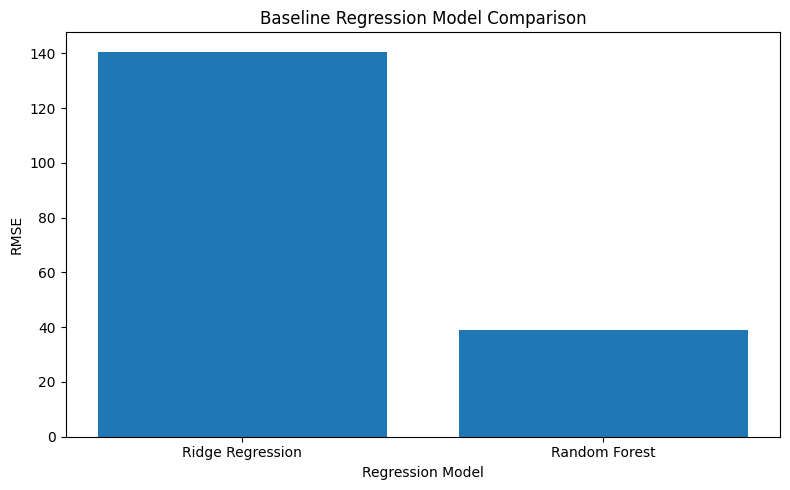

In [ ]:
# ============================================================
# CELL 55 - BASELINE RMSE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    baseline_results.index,
    baseline_results["RMSE"]
)

plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.title("Baseline Regression Model Comparison")

plt.tight_layout()
plt.show()

### 21.Baseline Model Interpretation

The Ridge Regression is tuned by means of GridSearchCV with five-fold cross-validation. The major hyperparameter is alpha and this determines the strength of regularisation. A number of alpha values are put to test. The cross-validation training part is completed but the hold-out test set remains untouched until the end (Jin and Ma, 2026). The use of the pipeline ensures that preprocessing is optimally adjusted to the cross-validation process that reduces the risk of information leaking. This has played a particularly vital role, in the sense that any alterations such as imputation, scaling and one-hot encoding could otherwise reach the information of validation observations before the model evaluation. By having preprocessing and regression model in a single pipeline, each cross-validation fold can find the transformation parameters needed on its own training set and subsequently transform the validation set with the transformation parameters found (Mundada et al., 2026). This gives a more realistic evaluation of the performance of the whole modelling process on the hidden observations. The methodology also enhances reproducibility since the same order of transformations are always used throughout the training, validation and end test.

## 22. Ridge Hyperparameter Interpretation

The graph shows how the cross-validation RMSE changes with the regularisation strengths that have been tried. A smaller validation RMSE means the more predictive the performance in the training cross-validation. The alpha to be selected is the one that is accompanied with minimum cross-validation RMSE (Khulbe, Belyi and Sobolevsky, 2025).
This is chosen so that the final test set can be left out of the selection so that it can be an unbiased hold-out test.


In [ ]:
# ============================================================
# CELL 58 - RIDGE HYPERPARAMETER TUNING
# ============================================================

ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_B
        ),
        (
            "model",
            Ridge()
        )
    ]
)

ridge_param_grid = {
    "model__alpha": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)

ridge_grid.fit(
    X_train,
    y_train
)

print("Ridge tuning completed.")

print("\nBest Ridge parameters:")
print(ridge_grid.best_params_)

print(
    "\nBest Ridge CV RMSE:",
    round(-ridge_grid.best_score_, 3)
)

Ridge tuning completed.

Best Ridge parameters:
{'model__alpha': 100.0}

Best Ridge CV RMSE: 140.868


In [ ]:
# ============================================================
# CELL 59 - RIDGE GRID SEARCH RESULTS
# ============================================================

ridge_cv_results = pd.DataFrame(
    ridge_grid.cv_results_
)

ridge_cv_results["CV_RMSE"] = (
    -ridge_cv_results["mean_test_score"]
)

ridge_cv_results["Train_RMSE"] = (
    -ridge_cv_results["mean_train_score"]
)

ridge_summary = ridge_cv_results[
    [
        "param_model__alpha",
        "CV_RMSE",
        "Train_RMSE",
        "std_test_score"
    ]
].sort_values(
    "CV_RMSE"
)

display(
    ridge_summary.round(3)
)

,param_model__alpha,CV_RMSE,Train_RMSE,std_test_score
4,100.00,140.868,140.629,2.679
3,10.00,140.875,140.596,2.657
2,1.00,140.882,140.594,2.655
1,0.10,140.883,140.593,2.655
0,0.01,140.883,140.593,2.655


In [ ]:
# ============================================================
# CELL 59 - RIDGE GRID SEARCH RESULTS
# ============================================================

ridge_cv_results = pd.DataFrame(
    ridge_grid.cv_results_
)

ridge_cv_results["CV_RMSE"] = (
    -ridge_cv_results["mean_test_score"]
)

ridge_cv_results["Train_RMSE"] = (
    -ridge_cv_results["mean_train_score"]
)

ridge_summary = ridge_cv_results[
    [
        "param_model__alpha",
        "CV_RMSE",
        "Train_RMSE",
        "std_test_score"
    ]
].sort_values(
    "CV_RMSE"
)

display(
    ridge_summary.round(3)
)

,param_model__alpha,CV_RMSE,Train_RMSE,std_test_score
4,100.00,140.868,140.629,2.679
3,10.00,140.875,140.596,2.657
2,1.00,140.882,140.594,2.655
1,0.10,140.883,140.593,2.655
0,0.01,140.883,140.593,2.655


## 23. Hyperparameter Tuning: Random Forest
Random Forest also has a number of hyperparameters which are n_estimators controls the number of trees in the ensemble, while max_depth controls maximum tree depth. min_samples_split and min_samples_leaf influence the minimum amount of data required for further splitting and terminal nodes (Kruschel et al., 2026).

In [ ]:
# ============================================================
# CELL 63 - RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_B
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

rf_param_grid = {
    "model__n_estimators": [
        100,
        200
    ],
    "model__max_depth": [
        10,
        20,
        None
    ],
    "model__min_samples_split": [
        2,
        5
    ],
    "model__min_samples_leaf": [
        1,
        2
    ]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)

print("Starting Random Forest GridSearchCV...")

rf_grid.fit(
    X_train,
    y_train
)

print("Random Forest tuning completed.")

print("\nBest Random Forest parameters:")
print(rf_grid.best_params_)

print(
    "\nBest Random Forest CV RMSE:",
    round(-rf_grid.best_score_, 3)
)

Starting Random Forest GridSearchCV...
Random Forest tuning completed.

Best Random Forest parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Random Forest CV RMSE: 41.671


In [ ]:
# ============================================================
# CELL 64 - RANDOM FOREST TUNING RESULTS
# ============================================================

rf_cv_results = pd.DataFrame(
    rf_grid.cv_results_
)

rf_cv_results["CV_RMSE"] = (
    -rf_cv_results["mean_test_score"]
)

rf_cv_results["Train_RMSE"] = (
    -rf_cv_results["mean_train_score"]
)

rf_summary = rf_cv_results.sort_values(
    "CV_RMSE"
)

display(
    rf_summary[
        [
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__min_samples_split",
            "param_model__min_samples_leaf",
            "CV_RMSE",
            "Train_RMSE"
        ]
    ].head(10).round(3)
)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,CV_RMSE,Train_RMSE
17,200,None,2,1,41.671,15.517
9,200,20,2,1,41.748,15.623
16,100,None,2,1,41.839,15.742
8,100,20,2,1,41.849,15.853
19,200,None,5,1,41.978,20.165
11,200,20,5,1,41.996,20.235
21,200,None,2,2,42.014,21.227
18,100,None,5,1,42.103,20.338
13,200,20,2,2,42.104,21.269
10,100,20,5,1,42.121,20.413


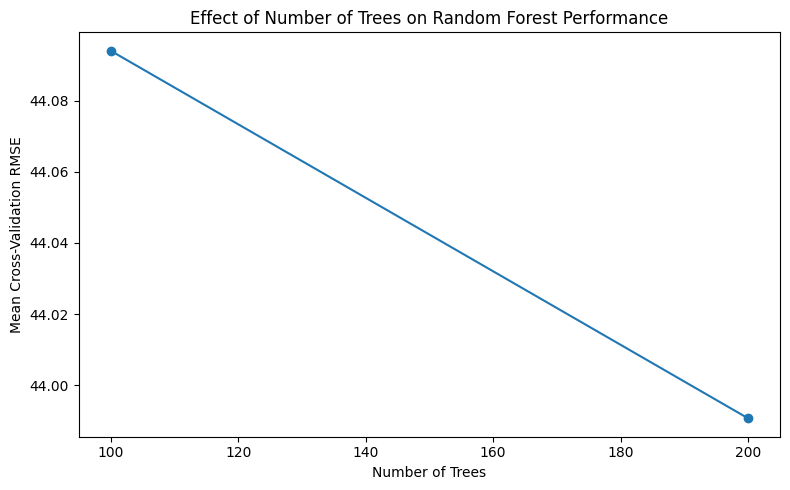

In [ ]:
# ============================================================
# CELL 65 - RANDOM FOREST HYPERPARAMETER VISUALISATION
# ============================================================

rf_tree_effect = (
    rf_summary
    .groupby(
        "param_model__n_estimators",
        dropna=False
    )["CV_RMSE"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.plot(
    rf_tree_effect[
        "param_model__n_estimators"
    ].astype(int),
    rf_tree_effect["CV_RMSE"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("Mean Cross-Validation RMSE")
plt.title(
    "Effect of Number of Trees on Random Forest Performance"
)

plt.tight_layout()
plt.show()

### 23.Random Forest Hyperparameter Interpretation

The Random Forest grid search algorithm does a grid search over the combinations of ensemble size and tree complexity. The presented results determine the configurations that have the lowest cross-validation RMSE.
The configuration identified should be considered as the most effective configuration in the parameter grid under test, and not the universal best Random Forest configuration (Mohamed, Mohamed and Maatouk, 2025). The training and validation errors might also be compared to assess indications of excessive complexity of model.


In [ ]:
# ============================================================
# CELL 67 - BEST HYPERPARAMETER CONFIGURATIONS
# ============================================================

print("BEST RIDGE CONFIGURATION")
print("-" * 50)
print(ridge_grid.best_params_)
print(
    "Best CV RMSE:",
    round(-ridge_grid.best_score_, 3)
)

print("\nBEST RANDOM FOREST CONFIGURATION")
print("-" * 50)
print(rf_grid.best_params_)
print(
    "Best CV RMSE:",
    round(-rf_grid.best_score_, 3)
)

BEST RIDGE CONFIGURATION
--------------------------------------------------
{'model__alpha': 100.0}
Best CV RMSE: 140.868

BEST RANDOM FOREST CONFIGURATION
--------------------------------------------------
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV RMSE: 41.671


## 25. Final Tuned Models
The optimum estimator that was outputted by each grid search includes the preprocessing pipeline as well as the tuned regression model. These estimators are now being used to make predictions of the previously untested hold-out test set (Mundada et al., 2026). The observations of the hold-out test are not further used to select hyperparameters.

In [ ]:
# ============================================================
# CELL 69 - RETRIEVE FINAL TUNED MODELS
# ============================================================

best_ridge = ridge_grid.best_estimator_
best_rf = rf_grid.best_estimator_

print("Best Ridge model retrieved successfully.")
print("Best Random Forest model retrieved successfully.")

Best Ridge model retrieved successfully.
Best Random Forest model retrieved successfully.


In [ ]:
# ============================================================
# CELL 69 - RETRIEVE FINAL TUNED MODELS
# ============================================================

best_ridge = ridge_grid.best_estimator_
best_rf = rf_grid.best_estimator_

print("Best Ridge model retrieved successfully.")
print("Best Random Forest model retrieved successfully.")

Best Ridge model retrieved successfully.
Best Random Forest model retrieved successfully.


## 26. Final Model Evaluation

The last assessment is based on the unseen hold-out test set that is developed prior to the development of a model. There are four regression measures listed: MAE, MSE, RMSE and R².
MAE offers the mean absolute prediction error (Peng et al., 2024). MSE pays more attention to bigger errors since the errors are squared. RMSE has the error of prediction on the same numerical scale as the target and is also sensitive to big errors. R² is the proportion of change in demand that is captured by the model.
The indicators are taken as a set in order to have a balanced assessment.


In [ ]:
# ============================================================
# CELL 72 - REGRESSION METRICS FUNCTION
# ============================================================

def calculate_regression_metrics(
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [ ]:
# Check that the tuned models exist
if "ridge_grid" not in globals():
    raise NameError(
        "ridge_grid was not found. Run the Ridge GridSearchCV cell first."
    )

if "rf_grid" not in globals():
    raise NameError(
        "rf_grid was not found. Run the Random Forest GridSearchCV cell first."
    )

# Generate predictions using the best tuned estimators
ridge_final_pred = ridge_grid.best_estimator_.predict(X_test)
rf_final_pred = rf_grid.best_estimator_.predict(X_test)

# Calculate metrics
ridge_final_metrics = calculate_regression_metrics(
    y_test,
    ridge_final_pred
)

rf_final_metrics = calculate_regression_metrics(
    y_test,
    rf_final_pred
)

# Compare final models
final_results = pd.DataFrame(
    [ridge_final_metrics, rf_final_metrics],
    index=["Tuned Ridge", "Tuned Random Forest"]
)

display(final_results.round(3))

,MAE,MSE,RMSE,R2
Tuned Ridge,104.956,19767.306,140.596,0.401
Tuned Random Forest,24.247,1506.158,38.809,0.954


### 27.Final Evaluation Interpretation

The last table presents the performance of the both tuned models on the observations that were not included in the model fitting and hyperparameter selection (Rahouti et al., 2021). Calculated values should be interpreted into the results.
Lower MAE and RMSE will imply the errors in the prediction are lower and higher R² will imply that it will capture more of the variation in the observed demand. The complete metric profile is then the model that needs to be talked about in relation to the final model as opposed to the single performance measure.


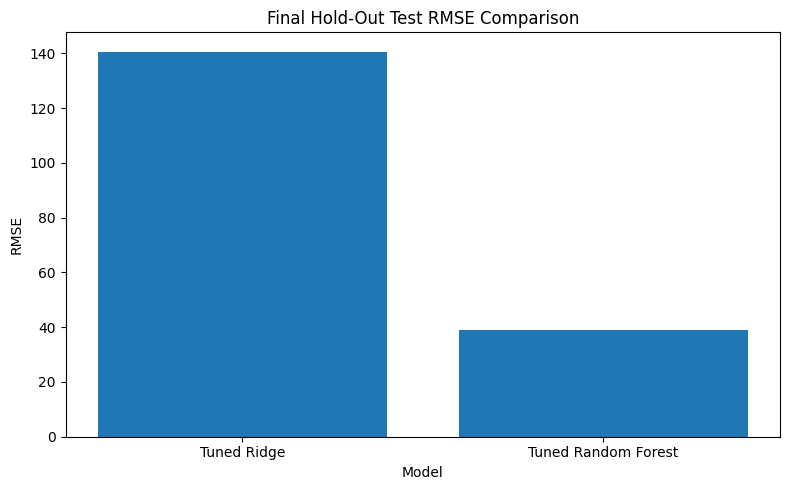

In [ ]:
# ============================================================
# CELL 75 - FINAL RMSE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    final_results.index,
    final_results["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title(
    "Final Hold-Out Test RMSE Comparison"
)

plt.tight_layout()
plt.show()

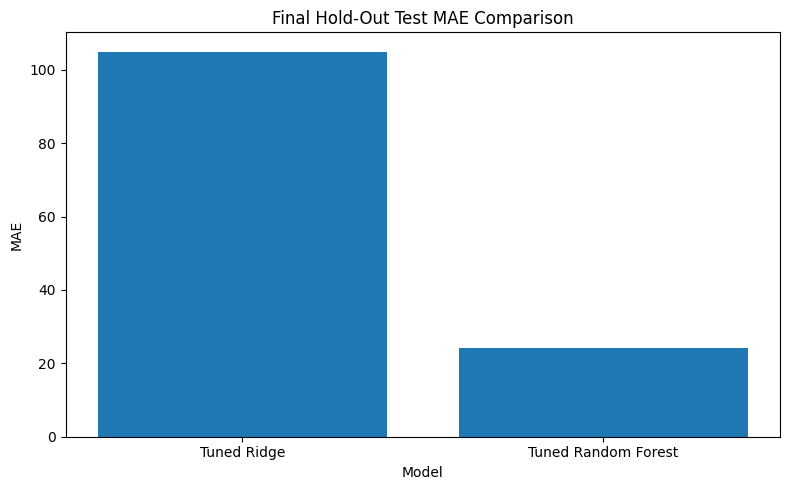

In [ ]:
# ============================================================
# CELL 76 - FINAL MAE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    final_results.index,
    final_results["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title(
    "Final Hold-Out Test MAE Comparison"
)

plt.tight_layout()
plt.show()

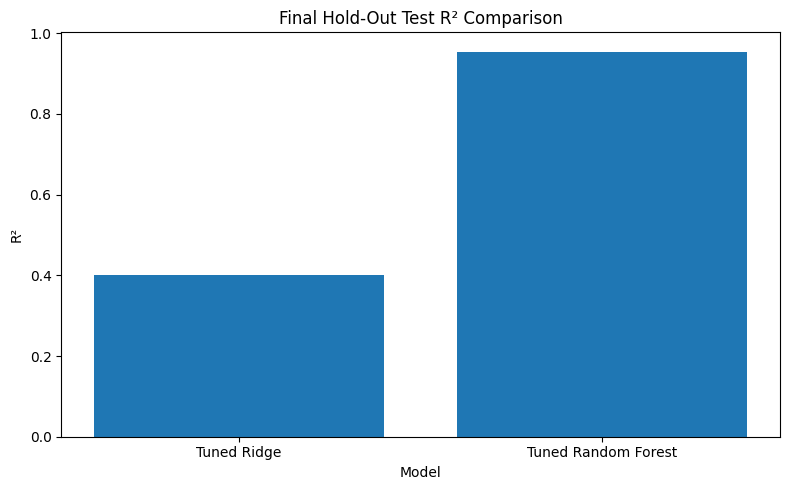

In [ ]:
# ============================================================
# CELL 77 - FINAL R² COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    final_results.index,
    final_results["R2"]
)

plt.xlabel("Model")
plt.ylabel("R²")
plt.title(
    "Final Hold-Out Test R² Comparison"
)

plt.tight_layout()
plt.show()

## 28. Final Model Selection

The last model is chosen based on the evidence provided by cross-validation and unseen hold-out testing. Comparison of RMSE, MAE and R².
The options listed below are not made with any presumption, but based on the actual results of the experiments and not the assumption that either Ridge Regression or Random Forest will always be the superior of the two (Somanath et al., 2024).


In [ ]:
# ============================================================
# CELL 79 - FINAL MODEL SELECTION
# ============================================================

ridge_rmse = final_results.loc[
    "Tuned Ridge",
    "RMSE"
]

rf_rmse = final_results.loc[
    "Tuned Random Forest",
    "RMSE"
]

if rf_rmse < ridge_rmse:

    final_model = best_rf
    final_predictions = rf_final_pred
    final_model_name = "Tuned Random Forest"

else:

    final_model = best_ridge
    final_predictions = ridge_final_pred
    final_model_name = "Tuned Ridge"

print("Selected final model:", final_model_name)
print(
    "Final hold-out RMSE:",
    round(
        final_results.loc[
            final_model_name,
            "RMSE"
        ],
        3
    )
)

Selected final model: Tuned Random Forest
Final hold-out RMSE: 38.809


## 29. Actual versus Predicted Demand

The extent to which the final model predictions align with the observed demand is analysed with the assistance of an actual-versus-predicted plot (Chen, Thakuriah and Ampountolas, 2021). One that displays perfect prediction is called diagonal reference line. Values that are close to the line have the least difference between the actual and predicted values. The bigger deviations are used to determine which observations the model over- or under-predicted. The reference line which is diagonal shows the situation in which the predicted demand equals the actual demand. Thus, observations around this line show that the estimates of the model are similar to the counts of rentals observed. On the other hand, the observations that are further along the line have larger discrepancies and can reflect the periods that were more challenging to the model to forecast (Mohseni, Nourinejad and Park, 2026). The points distribution on the plot also gives a clue as to whether the accuracy of prediction is relatively constant at various levels of demand. As the points become more widely dispersed as the real demand is increasing, this can indicate that the model faces more challenges forecasting the periods of increased rental volumes. This would be operationally important because any inaccurate forecasts during high demand times of the bikes and the scheduling of the resources could affect availability of bikes.
This plot therefore complements the measures of the numerical assessment measures showing the personal prediction behaviour of the ultimate model. Unlike MAE and RMSE which give a general understanding of the error in prediction, the actual-versus-predicted visualisation would allow one to identify the position of errors. It can subsequently support further studies on abnormal observation, potential feature restrictions and opportunities of further feature engineering.


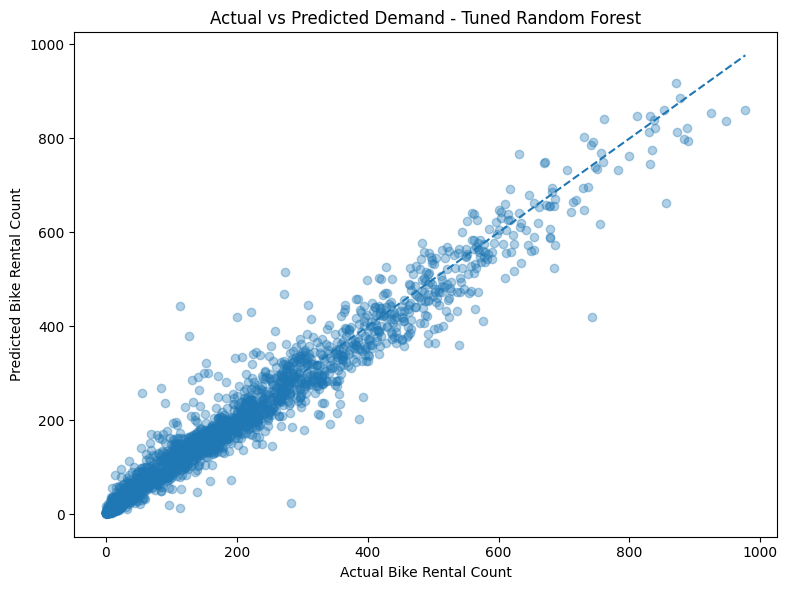

In [ ]:
# ============================================================
# CELL 81 - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.35
)

minimum_value = min(
    y_test.min(),
    final_predictions.min()
)

maximum_value = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.xlabel("Actual Bike Rental Count")
plt.ylabel("Predicted Bike Rental Count")

plt.title(
    f"Actual vs Predicted Demand - {final_model_name}"
)

plt.tight_layout()
plt.show()

## 30. Residual Analysis

The discrepancy between the actual and the forecasted is known as the residuals. The residual analysis helps identify systematic errors which might not have been evident based on aggregate measurements (Del-Coco et al., 2025). A trend about zero, and without an apparent systematic trend, would be happy to demonstrate that the model is not producing an apparent directional pattern in its errors. Huge residuals will be those with lesser prediction accuracy. These observations are cases where the difference between the actual demand in the respects of rental and demand which the model forecasts are quite high. It is essential to consider those residuals as an average performance measure can conceal certain circumstances where the model is unsuccessful in generating credible estimates. Positive large residuals mean that the actual demand was higher than the forecast and negative large residuals mean that the model had predicted that the demand would be higher than it was actually. Such differences may occur when we have abnormal demand spikes or combinations of factors that are less well reflected in the training data (Wang et al., 2025).
Distribution of residual can thus provide added information with respect to consistency of performance of the model across a variety of observations. When the larger errors are concentrated at certain levels of demand, it may be that the model is not doing so well in periods of low demand and high demand. This is particularly true with regard to bike-sharing operations because errors made during peak demand may have greater implications on operations than errors made during low demand. The residual analysis can also help to know whether the additional feature engineering or other predicting variables will help in predicting the accuracy. In general, the analysis of residuals helps to supplement MAE, MSE, RMSE and R² and gain a better idea of the location and nature of the errors in prediction.


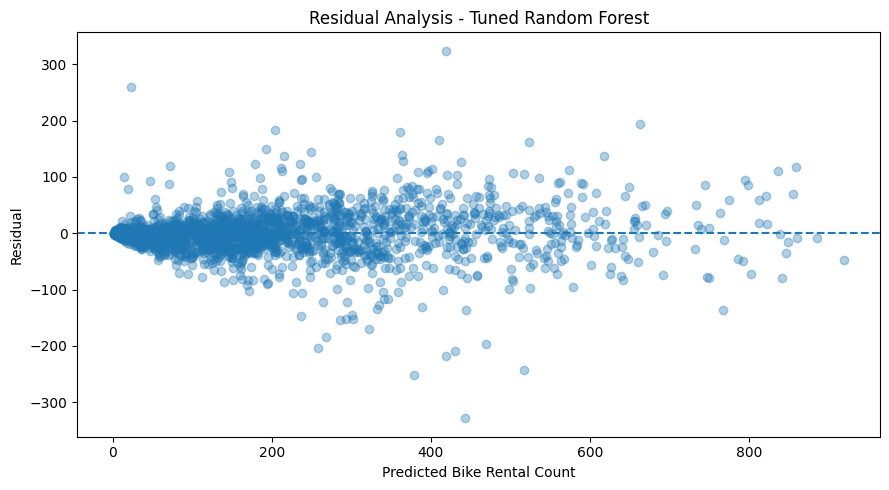

In [ ]:
# ============================================================
# CELL 83 - RESIDUAL ANALYSIS
# ============================================================

residuals = (
    y_test.to_numpy()
    - final_predictions
)

plt.figure(figsize=(9, 5))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.35
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Bike Rental Count")
plt.ylabel("Residual")
plt.title(
    f"Residual Analysis - {final_model_name}"
)

plt.tight_layout()
plt.show()

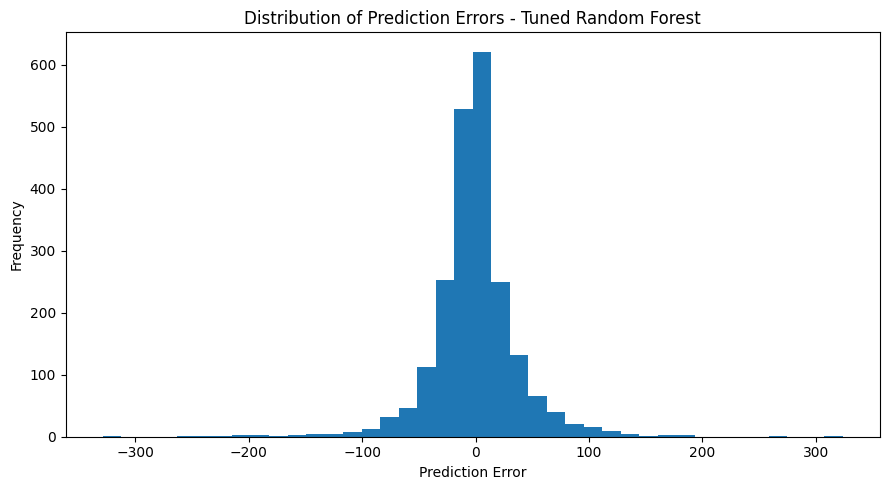

In [ ]:
# ============================================================
# CELL 84 - RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    residuals,
    bins=40
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title(
    f"Distribution of Prediction Errors - {final_model_name}"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 85 - ERROR ANALYSIS BY DEMAND LEVEL
# ============================================================

error_analysis = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": final_predictions
})

error_analysis["Absolute_Error"] = (
    np.abs(
        error_analysis["Actual"]
        - error_analysis["Predicted"]
    )
)

# Divide observations into four demand groups
error_analysis["Demand_Group"] = pd.qcut(
    error_analysis["Actual"],
    q=4,
    duplicates="drop"
)

error_by_group = (
    error_analysis
    .groupby(
        "Demand_Group",
        observed=True
    )["Absolute_Error"]
    .mean()
    .reset_index()
)

display(
    error_by_group.round(3)
)

,Demand_Group,Absolute_Error
0,"(0.999, 41.0]",7.007
1,"(41.0, 145.0]",22.328
2,"(145.0, 280.0]",26.117
3,"(280.0, 977.0]",41.646


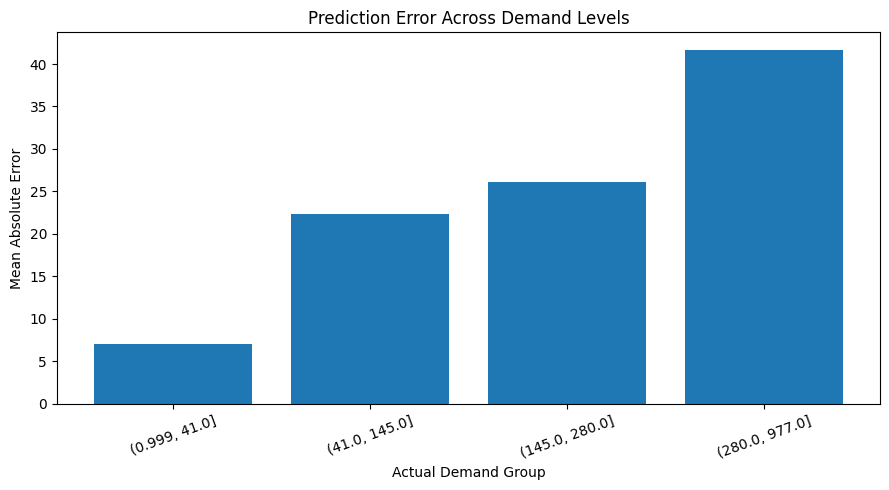

In [ ]:
# ============================================================
# CELL 86 - ERROR BY DEMAND LEVEL
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    error_by_group[
        "Demand_Group"
    ].astype(str),
    error_by_group[
        "Absolute_Error"
    ]
)

plt.xlabel("Actual Demand Group")
plt.ylabel("Mean Absolute Error")
plt.title(
    "Prediction Error Across Demand Levels"
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 31. Feature Importance and Explainability

The importance of features is investigated in the case of the Random Forest model due to the availability of the importance of transformed predictors of the fitted tree ensemble (Islam and Dhanekula, 2024). The analysis identifies variables that contributed significantly towards the predictive model. Predictive importance, however, is not to be understood that a variable directly affects the demand of bike-sharing. Explainability Model The model is also explainable since the analysis shows which of the transformed predictors is the greatest contributor to the predictions of the Random Forest. This could help to convert machine learning outputs into the form of a more understandable information to make operational decisions. Knowledge of the influential predictors can help managers know when to be more attentive, like when expected rental demand can vary in certain hours or environmental aspects.
Future data collection and feature engineering can also be guided by the findings. In the event that temporal variables exhibit high predictive value there might be time-varying aspects that are examined. In case the environmental variables are significant, then detail weather information might possibly be included. Overall, the feature-importance analysis provides the information about the internal predictive variant of the model without breaking the appropriate distinction between predictive association and causation.


In [ ]:
# ============================================================
# CELL 88 - RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Extract the fitted Random Forest
rf_model = best_rf.named_steps["model"]

# Extract the fitted preprocessing component
rf_preprocessor = (
    best_rf.named_steps["preprocessor"]
)

# Get transformed feature names
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

# Get importance values
importance_values = (
    rf_model.feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print("Top 15 predictive features:")
display(
    feature_importance.head(15).round(4)
)

Top 15 predictive features:


,Feature,Importance
7,numeric__hour,0.5977
4,numeric__year,0.0860
0,numeric__temp,0.0569
1,numeric__atemp,0.0464
5,numeric__month,0.0462
8,numeric__day_of_week,0.0370
16,categorical__workingday_1,0.0295
15,categorical__workingday_0,0.0293
2,numeric__humidity,0.0259
19,categorical__weather_3,0.0119


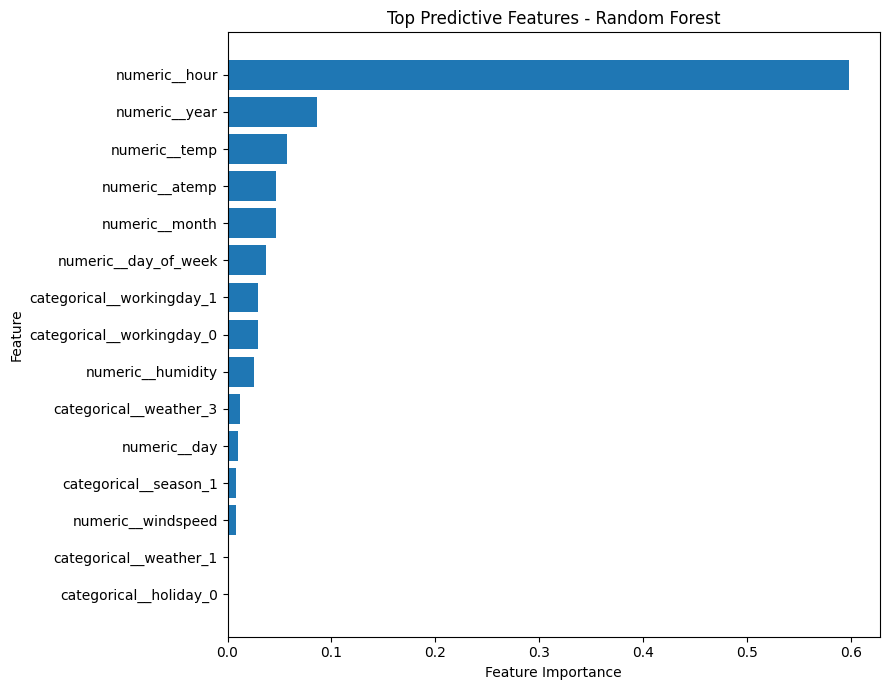


FINAL PROJECT SUMMARY

Selected final model:
Tuned Random Forest

Final test-set metrics:


,MAE,MSE,RMSE,R2
Tuned Random Forest,24.247,1506.158,38.809,0.954



Best Ridge parameters:
{'model__alpha': 100.0}

Best Random Forest parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Top five Random Forest features:


,Feature,Importance
7,numeric__hour,0.5977
4,numeric__year,0.0860
0,numeric__temp,0.0569
1,numeric__atemp,0.0464
5,numeric__month,0.0462



Business interpretation should connect
the observed predictive patterns to:
- bike availability
- operational planning
- resource allocation
- maintenance planning
- demand preparation


In [ ]:
# ============================================================
# CELL 89 - FEATURE IMPORTANCE VISUALISATION
# ============================================================

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top Predictive Features - Random Forest"
)

plt.tight_layout()
plt.show()


# ============================================================
# AUTOMATIC SUMMARY VALUES FOR REPORT WRITING
# ============================================================

print("\n" + "=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print("\nSelected final model:")
print(final_model_name)

print("\nFinal test-set metrics:")
display(
    final_results.loc[
        [final_model_name]
    ].round(3)
)

print("\nBest Ridge parameters:")
print(ridge_grid.best_params_)

print("\nBest Random Forest parameters:")
print(rf_grid.best_params_)

print("\nTop five Random Forest features:")

display(
    feature_importance.head(5).round(4)
)

print("\nBusiness interpretation should connect")
print("the observed predictive patterns to:")
print("- bike availability")
print("- operational planning")
print("- resource allocation")
print("- maintenance planning")
print("- demand preparation")

In [ ]:
# ============================================================
# CELL 90 - FINAL PROJECT VALIDATION CHECK
# ============================================================

print("=" * 70)
print("M505 BIKE-SHARING DEMAND PREDICTION")
print("FINAL PROJECT CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Dataset check
# ------------------------------------------------------------

print("\n1. DATASET")
print("-" * 50)

print("Training dataset shape:", df.shape)

if "external_test" in globals():
    print(
        "External test dataset shape:",
        external_test.shape
    )

# ------------------------------------------------------------
# 2. Target check
# ------------------------------------------------------------

print("\n2. TARGET")
print("-" * 50)

print("Target variable:", TARGET)

# ------------------------------------------------------------
# 3. Leakage check
# ------------------------------------------------------------

print("\n3. TARGET LEAKAGE CHECK")
print("-" * 50)

leakage_present = [
    column
    for column in ["casual", "registered"]
    if column in X.columns
]

if len(leakage_present) == 0:
    print(
        "PASS - casual and registered are excluded "
        "from the predictors."
    )
else:
    print(
        "WARNING - leakage variables found:",
        leakage_present
    )

# ------------------------------------------------------------
# 4. Train/test split check
# ------------------------------------------------------------

print("\n4. TRAIN/TEST SPLIT")
print("-" * 50)

print("Training observations:", len(X_train))
print("Hold-out observations:", len(X_test))

# ------------------------------------------------------------
# 5. Feature check
# ------------------------------------------------------------

print("\n5. FEATURE GROUPS")
print("-" * 50)

print(
    "Number of numerical features:",
    len(numerical_features)
)

print(
    "Number of categorical features:",
    len(categorical_features)
)

# ------------------------------------------------------------
# 6. Model check
# ------------------------------------------------------------

print("\n6. MODELS")
print("-" * 50)

print("Model 1: Ridge Regression")
print("Model 2: Random Forest Regression")

# ------------------------------------------------------------
# 7. Preprocessing check
# ------------------------------------------------------------

print("\n7. PREPROCESSING STRATEGIES")
print("-" * 50)

print("Strategy A: Imputation + Encoding")
print(
    "Strategy B: Imputation + Scaling + Encoding"
)

# ------------------------------------------------------------
# 8. Hyperparameter tuning check
# ------------------------------------------------------------

print("\n8. HYPERPARAMETER TUNING")
print("-" * 50)

print(
    "Ridge best parameters:",
    ridge_grid.best_params_
)

print(
    "Random Forest best parameters:",
    rf_grid.best_params_
)

# ------------------------------------------------------------
# 9. Final evaluation
# ------------------------------------------------------------

print("\n9. FINAL TEST-SET RESULTS")
print("-" * 50)

display(
    final_results.round(3)
)

# ------------------------------------------------------------
# 10. Prediction-length validation
# ------------------------------------------------------------

print("\n10. PREDICTION VALIDATION")
print("-" * 50)

print(
    "Actual test observations:",
    len(y_test)
)

print(
    "Final predictions:",
    len(final_predictions)
)

assert (
    len(y_test)
    == len(final_predictions)
)

print(
    "PASS - prediction and test-set lengths match."
)

# ------------------------------------------------------------
# 11. Missing prediction check
# ------------------------------------------------------------

print("\n11. PREDICTION QUALITY CHECK")
print("-" * 50)

nan_predictions = np.isnan(
    final_predictions
).sum()

print(
    "NaN predictions:",
    nan_predictions
)

assert nan_predictions == 0

print(
    "PASS - no NaN predictions."
)

# ------------------------------------------------------------
# 12. Final model
# ------------------------------------------------------------

print("\n12. SELECTED FINAL MODEL")
print("-" * 50)

print(final_model_name)

# ------------------------------------------------------------
# 13. Final feature importance
# ------------------------------------------------------------

print("\n13. TOP PREDICTIVE FEATURES")
print("-" * 50)

if "feature_importance" in globals():

    display(
        feature_importance
        .head(10)
        .round(4)
    )

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL STATUS")
print("=" * 70)

print(
    "The modelling pipeline completed successfully."
)

print(
    "Check the Markdown interpretations before submission."
)

print(
    "Run the complete notebook from the first cell "
    "to confirm reproducibility."
)

print("=" * 70)

M505 BIKE-SHARING DEMAND PREDICTION
FINAL PROJECT CHECK

1. DATASET
--------------------------------------------------
Training dataset shape: (10886, 12)
External test dataset shape: (6493, 9)

2. TARGET
--------------------------------------------------
Target variable: count

3. TARGET LEAKAGE CHECK
--------------------------------------------------
PASS - casual and registered are excluded from the predictors.

4. TRAIN/TEST SPLIT
--------------------------------------------------
Training observations: 8708
Hold-out observations: 2178

5. FEATURE GROUPS
--------------------------------------------------
Number of numerical features: 9
Number of categorical features: 4

6. MODELS
--------------------------------------------------
Model 1: Ridge Regression
Model 2: Random Forest Regression

7. PREPROCESSING STRATEGIES
--------------------------------------------------
Strategy A: Imputation + Encoding
Strategy B: Imputation + Scaling + Encoding

8. HYPERPARAMETER TUNING
------------

,MAE,MSE,RMSE,R2
Tuned Ridge,104.956,19767.306,140.596,0.401
Tuned Random Forest,24.247,1506.158,38.809,0.954



10. PREDICTION VALIDATION
--------------------------------------------------
Actual test observations: 2178
Final predictions: 2178
PASS - prediction and test-set lengths match.

11. PREDICTION QUALITY CHECK
--------------------------------------------------
NaN predictions: 0
PASS - no NaN predictions.

12. SELECTED FINAL MODEL
--------------------------------------------------
Tuned Random Forest

13. TOP PREDICTIVE FEATURES
--------------------------------------------------


,Feature,Importance
7,numeric__hour,0.5977
4,numeric__year,0.0860
0,numeric__temp,0.0569
1,numeric__atemp,0.0464
5,numeric__month,0.0462
8,numeric__day_of_week,0.0370
16,categorical__workingday_1,0.0295
15,categorical__workingday_0,0.0293
2,numeric__humidity,0.0259
19,categorical__weather_3,0.0119



FINAL STATUS
The modelling pipeline completed successfully.
Check the Markdown interpretations before submission.
Run the complete notebook from the first cell to confirm reproducibility.


## 32. Business Implications

The final model provides a data-driven approach to estimate the demand of bike-sharing based on operational, environmental and temporal data. The demand estimates can help in the planning of operations because it will enable the organisation to anticipate when the organisation will experience fluctuation in the levels of rental requirements (Jin and Ma, 2026). Results can be utilised to make decisions on the distribution of bikes, manage resources, time and prepare bikes in case the demand is high. The usefulness of these predictions in practice hinges on the accuracy of the observed models and whether the predictor information needed is available at the point of generation of predictions or not.
The feature-importance analysis also provides the data about the most important variables to the predictive model. This can be done with the results to target future data collection and improvements to the modelling.


## 33. Limitations and Deployment Considerations

The model relies on the historical variables that are present in the data. Prediction can be erroneous because of other factors that can influence the demand but are not provided in the features available. Such relationships are also reflective of the model based on historical data and therefore it requires further validation before it can be applied into practice (Kruschel et al., 2026).
A deployed model would demand a constant stream of data so that new data would go through the same process of feature engineering and the same preprocessing step as training. The performance of the prediction should also be monitored after the deployment as the performance can reduce because of changes in the user behaviour, weather patterns or operation conditions. Retraining should then be considered periodically when there is poor performance of the models.


## 34. Conclusion

The project developed an end-to-end machine learning model to forecast the demand of bike-sharing as a supervised regression problem. The structure and quality of the dataset were analysed with the help of exploratory analysis, and the original datetime variable was converted to potentially helpful calendar features with the help of temporal feature engineering.
Two preprocessing strategies were empirically compared and Ridge Regression and Random Forest Regression were compared. In scikit-learn, pipelines were fitted to both models and tuning was done on hyperparameters with cross-validation of five folds. The final performance was measured on a hidden test set hold-out in terms of MAE, MSE, RMSE and R².
The performed analysis provides the data about the predictive validity of the experimented methods and relevance of the different explanatory variables. Implications to business, limitations and deployment were also discussed. Further work might explore more explanatory variables, more feature engineering, other algorithms and continuous performance monitoring.
